# Fraud Detection Benchmark Using Machine Learning

Made by: Ranjan Verma

This notebook analyzes fraudulent online payment transactions using supervised machine learning models and compares multiple algorithms to identify the best-performing model.

## Problem Statement

Online payment fraud causes significant financial losses. The objective of this project is to build and compare machine learning classification models that can accurately detect fraudulent transactions while minimizing missed fraud cases.

In [1]:
# Importing Required Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, RocCurveDisplay, ConfusionMatrixDisplay

import joblib

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Dataset/paysim.csv')

# Preprocessing Data

In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [5]:
print(df['type'].unique())

['PAYMENT' 'TRANSFER' 'CASH_OUT' 'DEBIT' 'CASH_IN']


In [6]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [7]:
df.drop(columns = ['nameOrig', 'nameDest', 'isFlaggedFraud'], axis = 1, inplace = True)

In [8]:
df.isnull().sum()

,0
step,0
type,0
amount,0
oldbalanceOrg,0
newbalanceOrig,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [9]:
df.duplicated().sum()

np.int64(543)

In [10]:
df = df.drop_duplicates()

In [11]:
df.shape

(6362077, 8)

In [12]:
le = LabelEncoder()
df['type'] = le.fit_transform(df['type'])

# EDA

<Axes: >

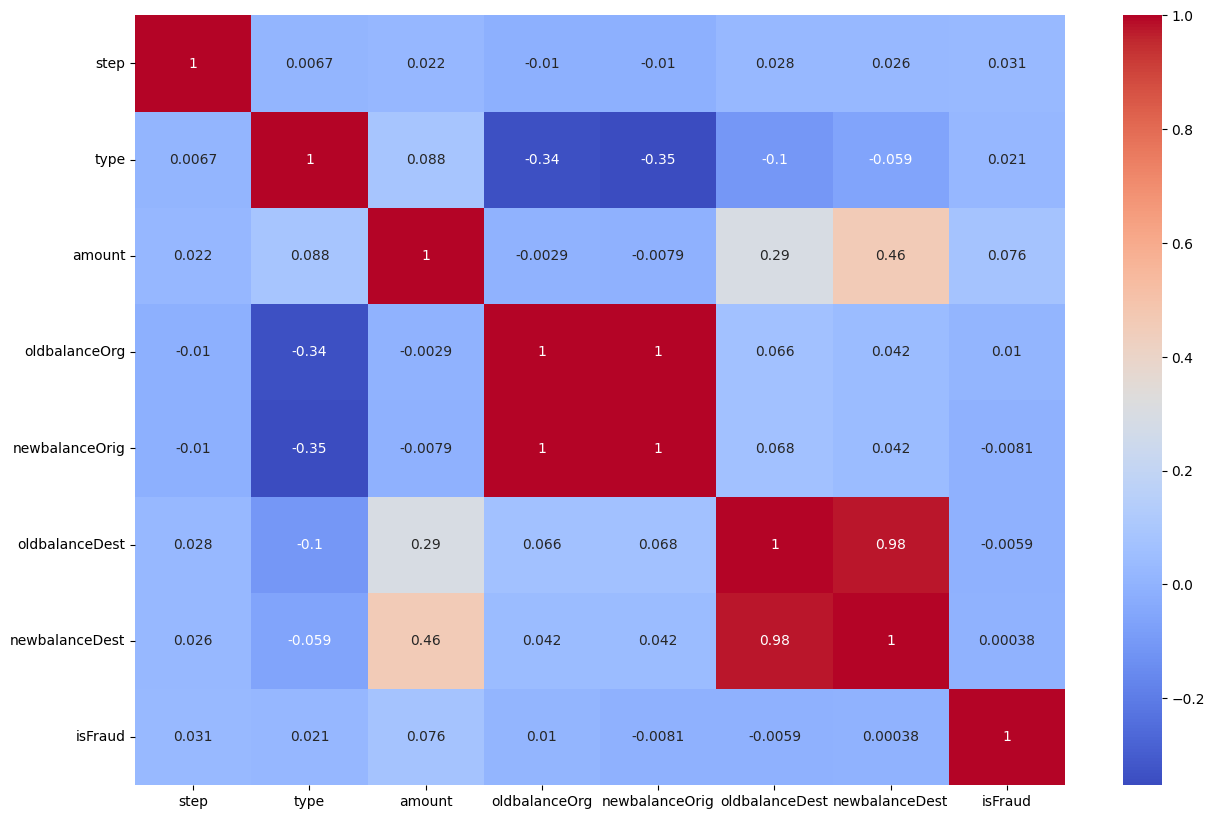

In [13]:
corr = df.corr()

plt.figure(figsize = (15, 10))
sns.heatmap(corr, annot = True, cmap = 'coolwarm')

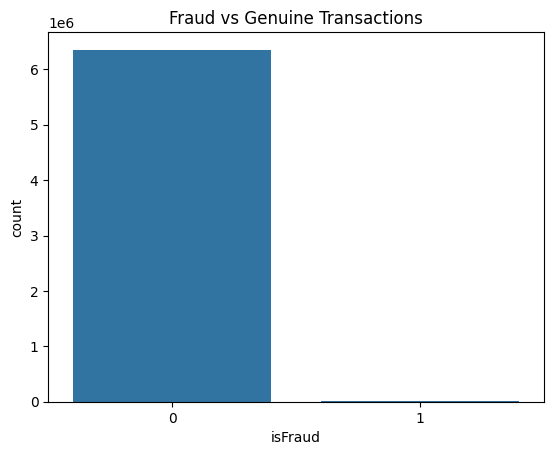

In [14]:
sns.countplot(x='isFraud', data=df)
plt.title("Fraud vs Genuine Transactions")
plt.show()

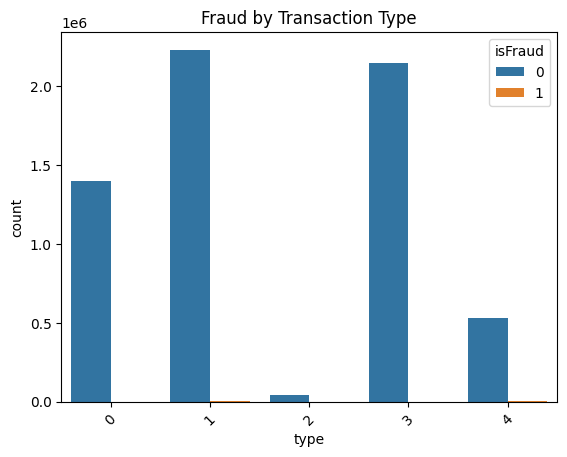

In [15]:
sns.countplot(x='type', hue='isFraud', data=df)
plt.title("Fraud by Transaction Type")
plt.xticks(rotation=45)
plt.show()

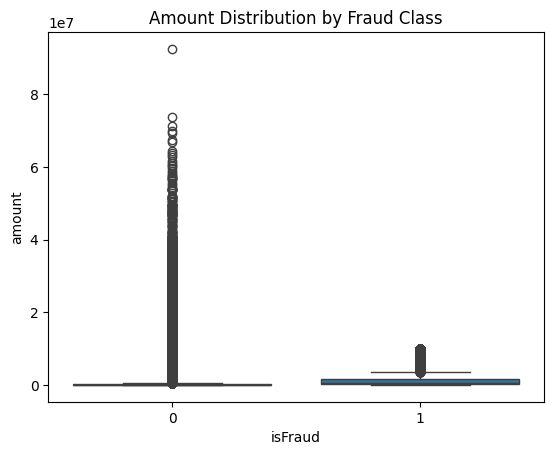

In [16]:
sns.boxplot(x='isFraud', y='amount', data=df)
plt.title("Amount Distribution by Fraud Class")
plt.show()

# Splitting the Dataset

In [17]:
# Using less data to decrease computing power
df = df.sample(300000, random_state=42)

In [18]:
X = df.drop('isFraud', axis = 1)
y = df['isFraud']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, stratify=y
)

In [20]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Training Models

## Random Forest

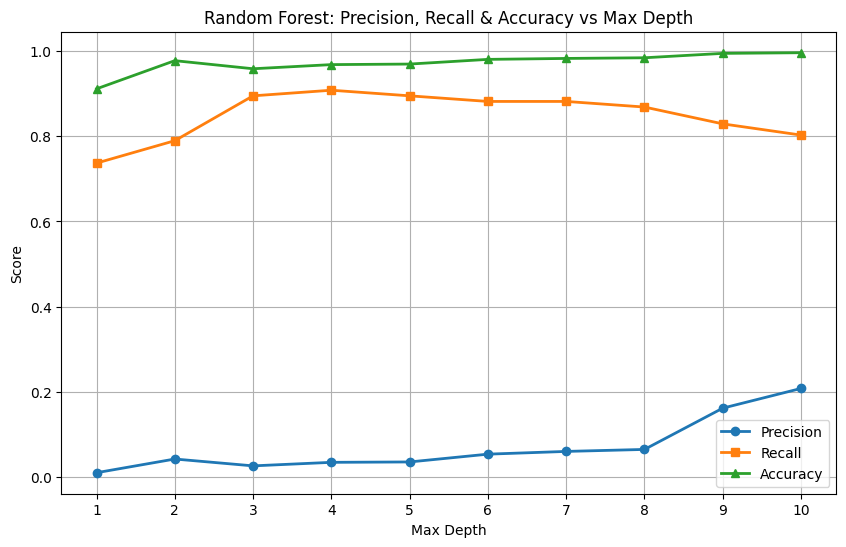

In [21]:
depths = range(1, 11)

precision_scores = []
recall_scores = []
accuracy_scores = []

for d in depths:

    rf = RandomForestClassifier(criterion='gini', max_depth=d, random_state=42, n_estimators = 30, n_jobs = -1, class_weight='balanced')

    rf.fit(X_train, y_train)
    pred_rf = rf.predict(X_test)

    precision_scores.append(precision_score(y_test, pred_rf))
    recall_scores.append(recall_score(y_test, pred_rf))
    accuracy_scores.append(accuracy_score(y_test, pred_rf))

plt.figure(figsize=(10,6))

plt.plot(depths, precision_scores, marker='o', linewidth=2, label='Precision')
plt.plot(depths, recall_scores, marker='s', linewidth=2, label='Recall')
plt.plot(depths, accuracy_scores, marker='^', linewidth=2, label='Accuracy')

plt.xlabel("Max Depth")
plt.ylabel("Score")
plt.title("Random Forest: Precision, Recall & Accuracy vs Max Depth")
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.show()

We are getting best and Reasonable results at max_depth 4

In [27]:
rf = RandomForestClassifier(criterion='gini', max_depth=4, random_state=42, n_estimators = 100, n_jobs = -1, class_weight='balanced')
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=4, n_jobs=-1,
                       random_state=42)

In [28]:
pred_rf = rf.predict(X_test)

In [29]:
print("Random Forest")

print("Accuracy Score: ", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

Random Forest
Accuracy Score:  0.9646
              precision    recall  f1-score   support

           0       1.00      0.96      0.98     59924
           1       0.03      0.91      0.06        76

    accuracy                           0.96     60000
   macro avg       0.52      0.94      0.52     60000
weighted avg       1.00      0.96      0.98     60000



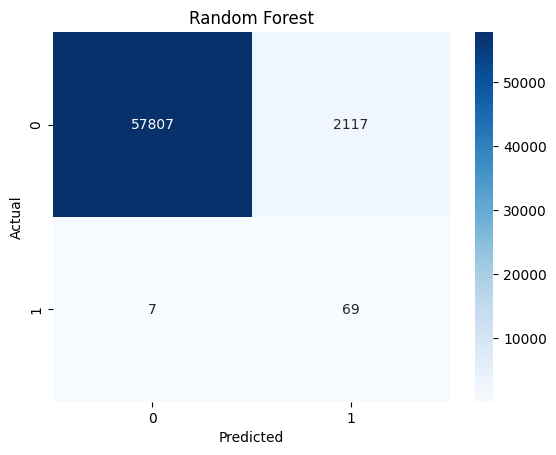

In [30]:
cm = confusion_matrix(y_test, pred_rf)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

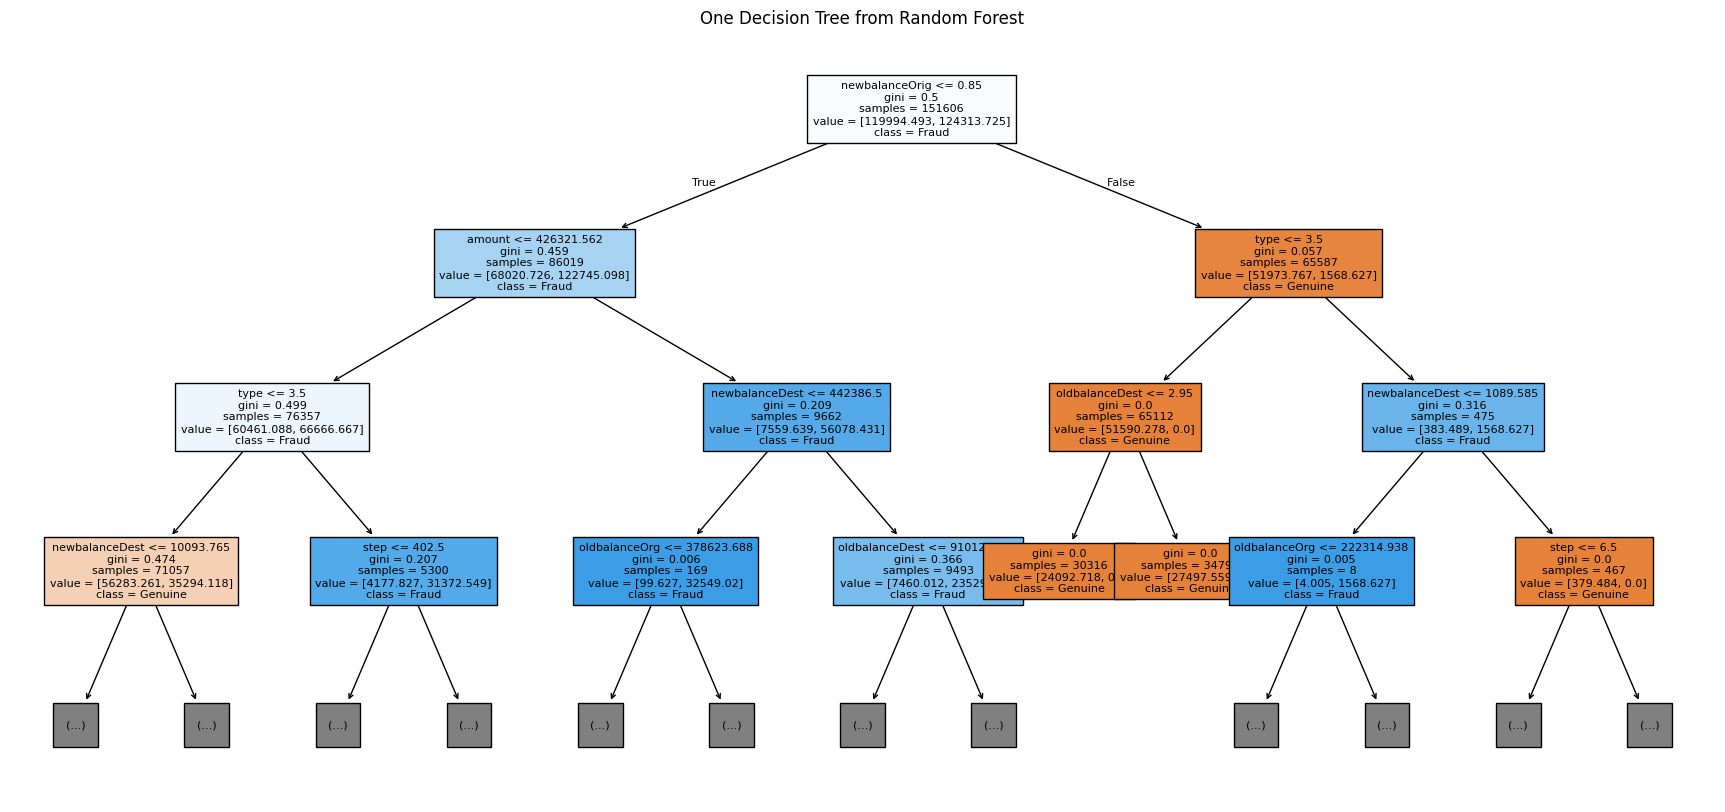

In [31]:
plt.figure(figsize=(22,10))
plot_tree(
    rf.estimators_[0],
    feature_names=X.columns,
    class_names=['Genuine','Fraud'],
    filled=True,
    max_depth=3,
    fontsize=8
)
plt.title("One Decision Tree from Random Forest")
plt.show()

Since the dataset is highly imbalanced, Precision, Recall, F1-score, and ROC-AUC were prioritized over Accuracy.

## Conclusion

Machine learning model was successfully applied to detect fraudulent transactions.